In [1]:
pip install insightface opencv-python-headless numpy matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 54.8 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp310-cp310-linux_x86_64.whl size=1055379 sha256=8ec246989d6ba45afd4b655add90aecbc36500326ed8b2aa4ef61fa73aae7a88
  Stored in directory: /root/.cache/pip/wheels/e3/d0/80/e3773fb8b6d1cca87ea1d33d9b1f20a223a6493c896da249b5
Successfully built insightface


In [3]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.3 MB/s eta 0:00:00


In [6]:
# pip install insightface opencv-python-headless numpy matplotlib
# !pip install onnxruntime # Install onnxruntime

SyntaxError: invalid syntax (<ipython-input-6-e493a87ae1e5>, line 1)

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis


In [17]:
# Create a FaceAnalysis object and load the required models
app = FaceAnalysis(allowed_modules=['detection', 'recognition'])  # Enable face detection and recognition modules
app.prepare(ctx_id=-1)  # Use CPU for processing; set a positive integer for GPU (e.g., ctx_id=0)



Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [22]:
# Load the target image (individual to find)
target_image_path = "/content/target.jpg"  # Path to the target image
target_image = cv2.imread(target_image_path)
target_image = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)  # Convert the image from BGR to RGB

# Load the crowd image (group photo)
crowd_image_path = "/content/crowd.jpeg"  # Path to the crowd image
crowd_image = cv2.imread(crowd_image_path)
crowd_image = cv2.cvtColor(crowd_image, cv2.COLOR_BGR2RGB)  # Convert the image from BGR to RGB


In [23]:
# Detect faces in the target image (individual to find)
target_faces = app.get(target_image)
if len(target_faces) == 0:
    print("No faces found in the target image!")  # Print a message if no faces are detected
    exit()

# Extract the feature (embedding) of the target face
target_feature = target_faces[0]['embedding']

# Detect faces in the crowd image (group photo)
crowd_faces = app.get(crowd_image)
if len(crowd_faces) == 0:
    print("No faces found in the crowd image!")  # Print a message if no faces are detected
    exit()



In [24]:
from numpy.linalg import norm

# Compare the faces
min_distance = float('inf')  # Initialize the minimum distance with infinity
best_match = None  # Variable to store the best matching face

# Loop through each face in the crowd image
for face in crowd_faces:
    crowd_feature = face['embedding']  # Get the embedding (feature vector) of the face
    distance = norm(target_feature - crowd_feature)  # Calculate the distance between feature vectors
    if distance < min_distance:  # If the current distance is smaller than the previous minimum
        min_distance = distance  # Update the minimum distance
        best_match = face  # Update the best match


# Check the result
if best_match is not None:
    print(f"Target individual identified with distance: {min_distance}")  # Print the distance to the best match
    bbox = best_match['bbox']  # Get the bounding box coordinates of the matched face
else:
    print("Target individual not found in the crowd image.")  # Print a message if no match is found



Target individual identified with distance: 23.592390060424805


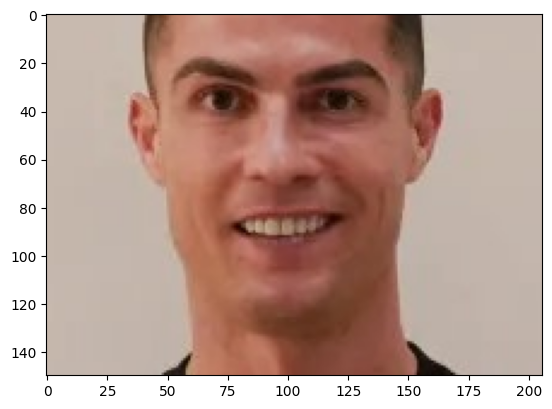

In [28]:
plt.imshow(target_image)  # Changed from "/content/target.jpg" to target_image which holds the image array
plt.show()  # Display the image

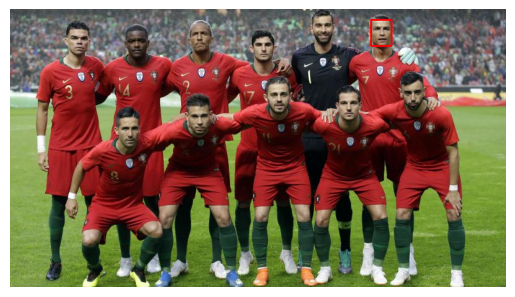

In [25]:
# Draw a rectangle around the identified face
if best_match is not None:
    x1, y1, x2, y2 = map(int, bbox)  # Get the bounding box coordinates and convert them to integers
    cv2.rectangle(crowd_image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Draw a blue rectangle around the face

# Display the image with the rectangle
plt.imshow(crowd_image)  # Show the image with the rectangle
plt.axis("off")  # Turn off the axis labels
plt.show()  # Display the image

